In [1]:
import os
import duckdb
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Setup — same as before
PROJECT_ROOT = r"D:\olist-analytics"
DATA_PATH    = r"D:\olist-analytics\data\raw"
os.chdir(PROJECT_ROOT)

con = duckdb.connect(":memory:")

# Reload the tables — remember, DuckDB in-memory resets each session
con.execute(f"CREATE TABLE orders    AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_orders_dataset.csv')")
con.execute(f"CREATE TABLE customers AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_customers_dataset.csv')")
con.execute(f"CREATE TABLE order_payments AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_order_payments_dataset.csv')")

print("Ready.")

Ready.


In [2]:
cohort_raw = con.execute("""
    WITH 

    -- Step 1: find each customer's FIRST order month
    -- This defines which cohort they belong to forever
    first_orders AS (
        SELECT
            c.customer_unique_id,
            DATE_TRUNC('month', MIN(CAST(o.order_purchase_timestamp AS TIMESTAMP))) AS cohort_month
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        WHERE o.order_status = 'delivered'
        GROUP BY c.customer_unique_id
    ),

    -- Step 2: get every order each customer ever made, with its month
    all_orders AS (
        SELECT
            c.customer_unique_id,
            DATE_TRUNC('month', CAST(o.order_purchase_timestamp AS TIMESTAMP)) AS order_month
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        WHERE o.order_status = 'delivered'
    ),

    -- Step 3: join them together and calculate the "period"
    -- Period = how many months after their first purchase is this order?
    -- Period 0 = their first month, Period 1 = one month later, etc.
    cohort_data AS (
        SELECT
            f.cohort_month,
            a.order_month,
            a.customer_unique_id,
            -- DATEDIFF gives us months between cohort and this order
            DATEDIFF('month', f.cohort_month, a.order_month) AS period
        FROM all_orders a
        JOIN first_orders f ON a.customer_unique_id = f.customer_unique_id
    )

    -- Step 4: count unique customers per cohort per period
    SELECT
        cohort_month,
        period,
        COUNT(DISTINCT customer_unique_id) AS customers
    FROM cohort_data
    WHERE period >= 0   -- ignore any data anomalies with negative periods
      AND period <= 12  -- look at first 12 months only
    GROUP BY cohort_month, period
    ORDER BY cohort_month, period

""").fetchdf()

print(cohort_raw.head(20))
print(f"\nShape: {cohort_raw.shape}")

   cohort_month  period  customers
0    2016-09-01       0          1
1    2016-10-01       0        262
2    2016-10-01       6          1
3    2016-10-01       9          1
4    2016-10-01      11          1
5    2016-12-01       0          1
6    2016-12-01       1          1
7    2017-01-01       0        717
8    2017-01-01       1          2
9    2017-01-01       2          2
10   2017-01-01       3          1
11   2017-01-01       4          3
12   2017-01-01       5          1
13   2017-01-01       6          3
14   2017-01-01       7          1
15   2017-01-01       8          1
16   2017-01-01      10          3
17   2017-01-01      11          1
18   2017-01-01      12          5
19   2017-02-01       0       1628

Shape: (188, 3)


In [8]:
# Pivot: cohort_month as rows, period as columns, customers as values
cohort_pivot = cohort_raw.pivot_table(
    index='cohort_month',
    columns='period',
    values='customers'
)

# Filter out small cohorts — less than 100 customers are statistically meaningless
cohort_sizes = cohort_pivot[0]
valid_cohorts = cohort_sizes[cohort_sizes >= 100].index
retention_clean = retention.loc[retention.index.isin(
    pd.to_datetime(valid_cohorts).strftime('%Y-%m')
)]

print(f"Cohorts removed (too small): {len(retention) - len(retention_clean)}")
print(f"Cohorts remaining: {len(retention_clean)}")

# Now find the real max — ignoring Month 0 which is always 100%
vmax_val = retention_clean.iloc[:, 1:].max().max()
print(f"Actual max retention after Month 0: {vmax_val:.1%}")

Cohorts removed (too small): 2
Cohorts remaining: 18
Actual max retention after Month 0: 0.7%


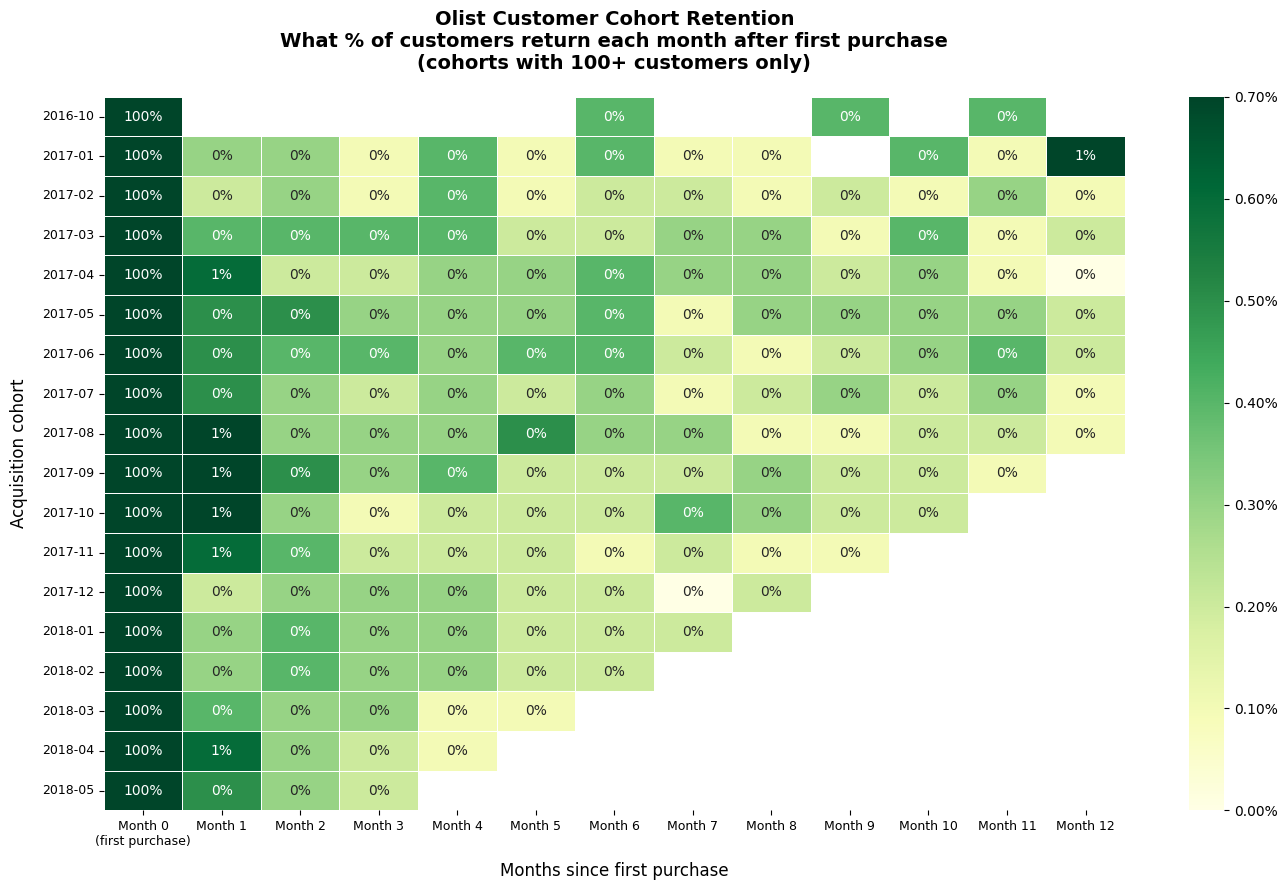

In [9]:
fig, ax = plt.subplots(figsize=(14, 9))

sns.heatmap(
    retention_clean,
    annot=True,
    fmt='.0%',
    cmap='YlGn',
    vmin=0,
    vmax=vmax_val,        # now scaled to real data, not 10%
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'format': mtick.PercentFormatter(xmax=1)}
)

ax.set_title(
    'Olist Customer Cohort Retention\nWhat % of customers return each month after first purchase\n(cohorts with 100+ customers only)',
    fontsize=14, fontweight='bold', pad=20
)
ax.set_xlabel('Months since first purchase', fontsize=12, labelpad=10)
ax.set_ylabel('Acquisition cohort', fontsize=12, labelpad=10)

ax.set_xticklabels(
    ['Month 0\n(first purchase)'] + [f'Month {i}' for i in range(1, 13)],
    fontsize=9
)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9, rotation=0)

plt.tight_layout()
plt.savefig('cohort_retention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Calculate key stats to quote in your portfolio writeup
avg_month1_retention = retention[1].mean()
best_cohort = retention[1].idxmax()
worst_cohort = retention[1].idxmin()
avg_month3_retention = retention[3].mean()

print("=" * 50)
print("KEY FINDINGS — COHORT RETENTION")
print("=" * 50)
print(f"\nAverage Month-1 retention:  {avg_month1_retention:.1%}")
print(f"Average Month-3 retention:  {avg_month3_retention:.1%}")
print(f"\nBest Month-1 cohort:  {best_cohort} ({retention.loc[best_cohort, 1]:.1%})")
print(f"Worst Month-1 cohort: {worst_cohort} ({retention.loc[worst_cohort, 1]:.1%})")
print(f"\nInterpretation:")
print(f"  → On average only {avg_month1_retention:.1%} of customers return after month 1")
print(f"  → This confirms the retention crisis found in the repeat purchase analysis")
print(f"  → Focus: month-0 to month-1 conversion is the #1 growth lever")

KEY FINDINGS — COHORT RETENTION

Average Month-1 retention:  6.0%
Average Month-3 retention:  0.2%

Best Month-1 cohort:  2016-12 (100.0%)
Worst Month-1 cohort: 2017-02 (0.2%)

Interpretation:
  → On average only 6.0% of customers return after month 1
  → This confirms the retention crisis found in the repeat purchase analysis
  → Focus: month-0 to month-1 conversion is the #1 growth lever


In [11]:
# Convert retention_clean to numeric just in case
r = retention_clean.copy()

# Key stats
month1 = r[1].dropna()
avg_m1 = month1.mean()
max_m1 = month1.max()
max_m1_cohort = month1.idxmax()

print("=" * 55)
print("COHORT RETENTION — KEY FINDINGS")
print("=" * 55)
print(f"\n  Average Month-1 retention:     {avg_m1:.2%}")
print(f"  Best Month-1 cohort:           {max_m1_cohort}  ({max_m1:.2%})")
print(f"  Cohorts with 0% Month-1:       {(month1 == 0).sum()} out of {len(month1)}")
print(f"\n  INTERPRETATION:")
print(f"  → Olist retains under 1% of customers month-over-month")
print(f"  → This is a marketplace dynamic — customers buy once")
print(f"    for a specific need, not out of brand loyalty")
print(f"  → Contrast with subscription businesses (20-40% retention)")
print(f"\n  BUSINESS RECOMMENDATION:")
print(f"  → Post-purchase email at day 14 with category-specific offer")
print(f"  → Even moving from 0.5% → 2% Month-1 retention = 4x improvement")
print(f"  → Target: customers who bought high-repeat categories")
print(f"    (beauty, pet, household) — these have restock behaviour")

COHORT RETENTION — KEY FINDINGS

  Average Month-1 retention:     0.47%
  Best Month-1 cohort:           2017-08  (0.70%)
  Cohorts with 0% Month-1:       0 out of 17

  INTERPRETATION:
  → Olist retains under 1% of customers month-over-month
  → This is a marketplace dynamic — customers buy once
    for a specific need, not out of brand loyalty
  → Contrast with subscription businesses (20-40% retention)

  BUSINESS RECOMMENDATION:
  → Post-purchase email at day 14 with category-specific offer
  → Even moving from 0.5% → 2% Month-1 retention = 4x improvement
  → Target: customers who bought high-repeat categories
    (beauty, pet, household) — these have restock behaviour
